In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class myCNN(torch.nn.Module):
    
    def __init__(self, input_channels : int, no_of_kernels : int, output_shape : int):
        super().__init__()

        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = input_channels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        self.block2 = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
                torch.nn.ReLU(),
                torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
                torch.nn.ReLU(),                    
                torch.nn.MaxPool2d(kernel_size = 2)
        )

        self.classifierblock = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = no_of_kernels * 7 * 7, out_features = output_shape)
        )

    def forward(self, x):
        return self.classifierblock(self.block2(self.block1(x)))

In [3]:
import torchvision
from torch.utils.data import DataLoader

In [4]:
train_data = torchvision.datasets.FashionMNIST(
    root = 'data',
    download = True,
    train = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

test_data = torchvision.datasets.FashionMNIST(
    root = 'data',
    download = True,
    train = False,
    transform = torchvision.transforms.ToTensor()
)

In [5]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
img, label = train_data[0]

In [7]:
img.shape

torch.Size([1, 28, 28])

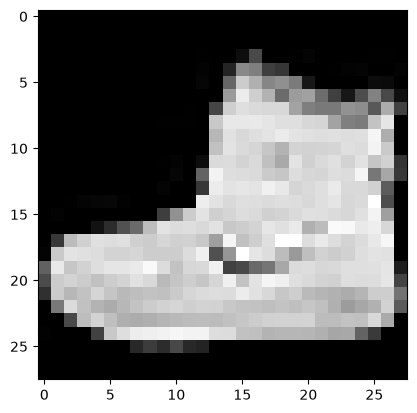

In [8]:
plt.imshow(img.squeeze(), cmap = 'gray')

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
device

'cuda'

In [11]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [12]:
model = myCNN(input_channels = 1, no_of_kernels = 10, output_shape = len(classes))

model

myCNN(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifierblock): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [13]:
model_path = r'C:\Users\offsh\Documents\project\dl\models\cnn_on_mnist_model.pth'

In [14]:
model.load_state_dict(torch.load( f = model_path))

<All keys matched successfully>

In [15]:
val = DataLoader(
    test_data,
    batch_size=1000,
    shuffle=False
)

In [16]:
model = model.to(device)

In [17]:
next(model.parameters()).device

device(type='cuda', index=0)

In [18]:
from torchmetrics import Accuracy

In [19]:
def test_model(model: torch.nn.Module, data: torch.utils.data.DataLoader , accuracy: Accuracy, device: torch.device = device):
    model = model.to(device)
    accuracy = accuracy.to(device)

    accuracy.reset()

    model.eval()

    with torch.inference_mode():
        for X, y in data:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            accuracy.update(y_pred, y)

    acc = accuracy.compute()

    print(f"model accuracy: {acc:.5f}")

In [20]:
accuracy = Accuracy(
    task = 'multiclass',
    num_classes = len(classes)
)

In [21]:
test_model(model = model, data = val, accuracy = accuracy, device = device)

model accuracy: 0.87850


In [22]:
def make_predictions( model: torch.nn.Module, data: torch.utils.data.DataLoader, device: torch.device = device ):

    model = model.to(device)
    model.eval()

    predictions = []

    with torch.inference_mode():

        for X, y in data:

            X = X.to(device)

            y_pred = model(X)

            predictions.append(y_pred.argmax(dim = 1).cpu())

    return torch.cat(predictions)

In [23]:
np.random.seed(42)

ls = np.random.randint(0, len(test_data), size=10)

data = []

for idx in ls:
    image, label = test_data[idx]
    data.append((image, label))

pred_data = DataLoader(
    data,
    batch_size = 10,
    shuffle = False
)

In [24]:
preds = make_predictions(model, pred_data, device)

In [25]:
preds

tensor([0, 6, 8, 8, 2, 1, 3, 8, 2, 5])

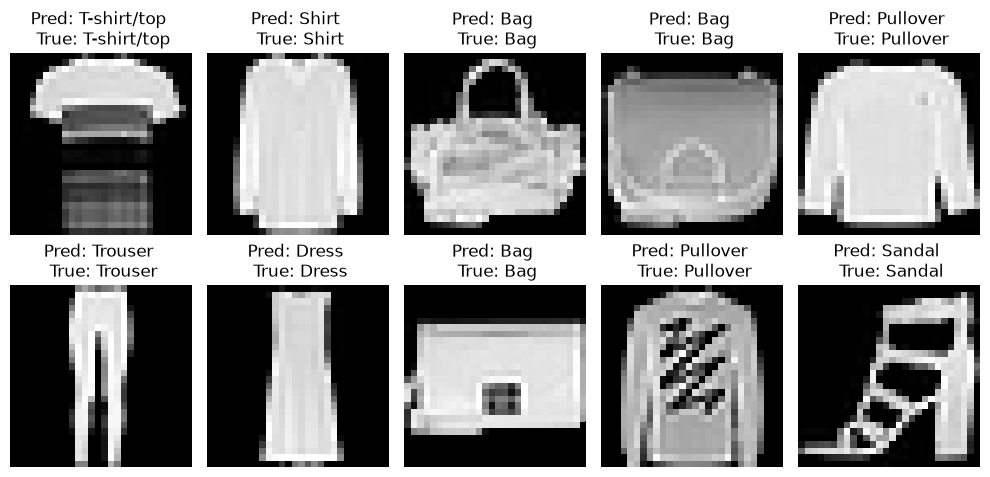

In [26]:
fig = plt.figure(figsize = (10, 5))

for i, (image, true_label) in enumerate(data):

    pred_label = preds[i].item()

    ax = fig.add_subplot(2, 5, i + 1)

    ax.imshow(image.squeeze(), cmap="gray")

    ax.set_title(f"Pred: {classes[pred_label]} \n True: {classes[true_label]}" )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from torchinfo import summary

In [29]:
summary(
    model = model,
    input_size = (1, 1, 28, 28)
)

Layer (type:depth-idx)                   Output Shape              Param #
myCNN                                    [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 14, 14]           --
│    └─Conv2d: 2-1                       [1, 10, 28, 28]           100
│    └─ReLU: 2-2                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 10, 28, 28]           910
│    └─ReLU: 2-4                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-5                       [1, 10, 28, 28]           910
│    └─ReLU: 2-6                         [1, 10, 28, 28]           --
│    └─MaxPool2d: 2-7                    [1, 10, 14, 14]           --
├─Sequential: 1-2                        [1, 10, 7, 7]             --
│    └─Conv2d: 2-8                       [1, 10, 14, 14]           910
│    └─ReLU: 2-9                         [1, 10, 14, 14]           --
│    └─Conv2d: 2-10                      [1, 10, 14, 14]           910
│    └─ReL

In [30]:
feature_map = None
gradient = None

In [32]:
def forward_hook(module, input, output):
    global feature_map
    feature_map = output.detach()

def backward_hook(module, grad_input, grad_output):
    global gradient
    gradient = grad_output[0].detach()

In [33]:
target = model.block2

In [34]:
forward_handle = target.register_forward_hook(forward_hook)
backward_handle = target.register_full_backward_hook(backward_hook)

In [41]:
np.random.seed(42)

idx = np.random.randint(0, len(test_data))


image, label = test_data[idx]

single_batch = image.unsqueeze(0)

In [42]:
single_batch.shape

torch.Size([1, 1, 28, 28])

In [45]:
model.eval()
single_batch = single_batch.to(device)
output = model(single_batch)

pred_class = output.argmax(dim=1).item()
output_class = classes[pred_class]
print(f"Model predicted: {output_class}")

model.zero_grad()
score = output[0, pred_class]
score.backward()

forward_handle.remove()
backward_handle.remove()

Model predicted: T-shirt/top


In [47]:
output_class, classes[label]

('T-shirt/top', 'T-shirt/top')

In [48]:
importance = torch.mean(gradient, dim = (2,3), keepdim = True)
gradient_weighted = importance * feature_map

In [49]:
gradient_weighted.shape

torch.Size([1, 10, 7, 7])

In [50]:
cam = torch.sum(gradient_weighted, dim = 1, keepdim = True)
cam.shape

torch.Size([1, 1, 7, 7])

In [51]:
cam = torch.nn.functional.relu(cam)
cam.shape

torch.Size([1, 1, 7, 7])

In [52]:
upsampled_cam = torch.nn.functional.interpolate(cam, size=(28, 28), mode='bilinear', align_corners=False)

In [53]:
upsampled_cam.shape

torch.Size([1, 1, 28, 28])

In [54]:
upsampled_cam = upsampled_cam - upsampled_cam.min()
upsampled_cam = upsampled_cam / (upsampled_cam.max() + 1e-8)

In [55]:
model_heatmap = upsampled_cam.squeeze().cpu().numpy()

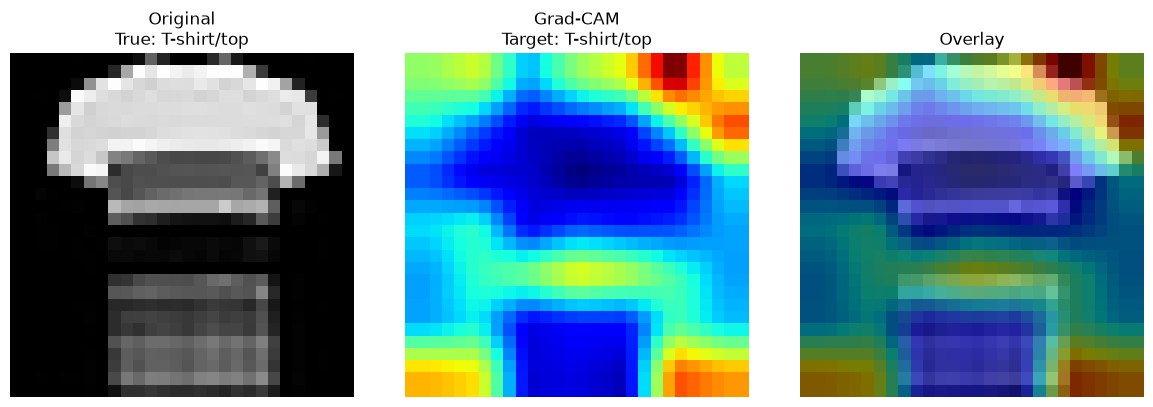

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].set_title(f"Original\nTrue: {classes[label]}")
axes[0].axis('off')

axes[1].imshow(model_heatmap, cmap='jet')
axes[1].set_title(f"Grad-CAM\nTarget: {output_class}")
axes[1].axis('off')

# Overlay
axes[2].imshow(image.squeeze(), cmap='gray')
axes[2].imshow(model_heatmap, cmap='jet', alpha=0.5)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

ACCORDING TO OUR GRADCAM OUT PUT OUR MODEL HAS FAILED TO LEARN AND HAVE MEMORISED EVEN THOUGHT IT HAVE NEVER SEEN THE TEST SAMPLE?

In [67]:
def grad_cam(model: torch.nn.Module, data_sample, target, device: torch.device = device):
    model = model.to(device)

    image, label = data_sample
    data = image.unsqueeze(0).to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, input, output):
        activations['value'] = output

    def backward_hook(module, grad_input, grad_output):
        gradients['value'] = grad_output[0] 

    forward_handle = target.register_forward_hook(forward_hook)
    backward_handle = target.register_full_backward_hook(backward_hook)
    
    try:
        model.eval()

        y_pred = model(data)

        pred_class = y_pred.argmax(dim=1).item()
        pred_class_name = classes[pred_class]

        model.zero_grad()
        score = y_pred[0, pred_class]
        score.backward()

        feature_map = activations['value']
        gradient = gradients['value']

        importance = torch.mean(gradient, dim=(2,3), keepdim=True)
        gradient_weighted = importance * feature_map

        cam = torch.sum(gradient_weighted, dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        upsampled_cam = torch.nn.functional.interpolate(cam, size=(28, 28), mode='bilinear', align_corners=False)

        upsampled_cam = upsampled_cam - upsampled_cam.min()
        upsampled_cam = upsampled_cam / (upsampled_cam.max() + 1e-8)

        model_heatmap = upsampled_cam.squeeze().detach().cpu().numpy() 

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(image.squeeze().detach().cpu().numpy(), cmap='gray')
        axes[0].set_title(f"Original\nTrue: {classes[label]}")
        axes[0].axis('off')

        axes[1].imshow(model_heatmap, cmap='jet')
        axes[1].set_title(f"Grad-CAM\nTarget: {pred_class_name}")
        axes[1].axis('off')

        # Overlay
        axes[2].imshow(image.squeeze().detach().cpu().numpy(), cmap='gray')
        axes[2].imshow(model_heatmap, cmap='jet', alpha=0.5)
        axes[2].set_title("Overlay")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

    finally:
        forward_handle.remove()
        backward_handle.remove()

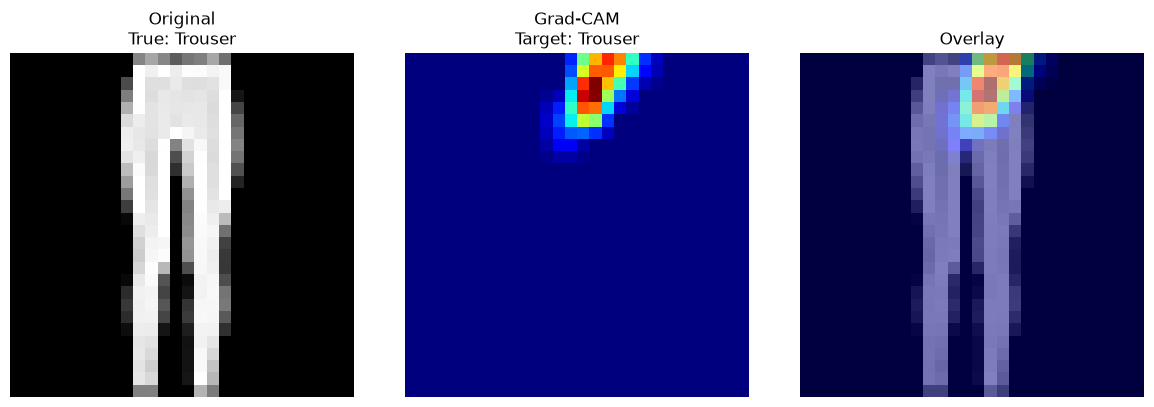

In [68]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

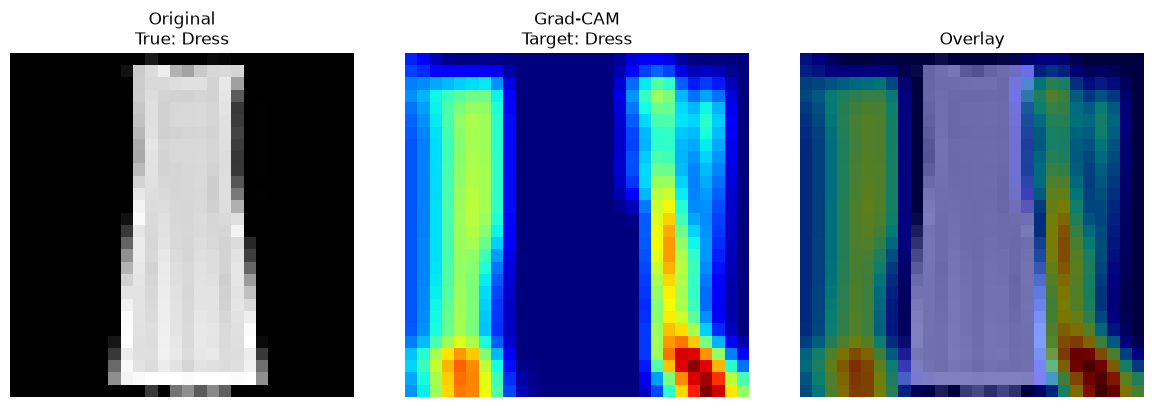

In [69]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

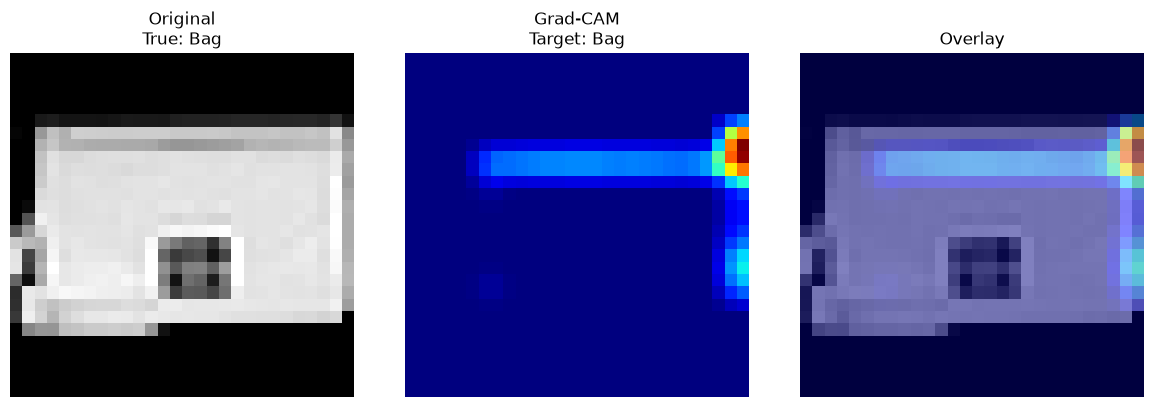

In [70]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

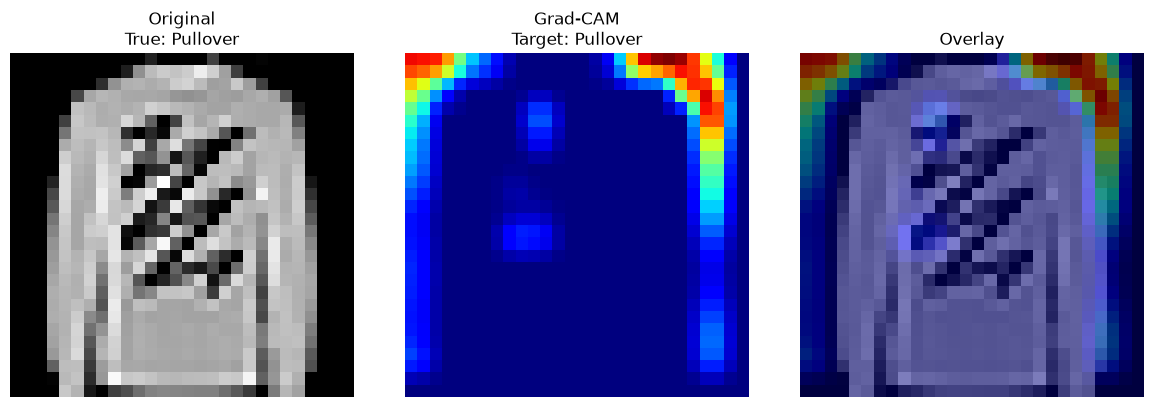

In [71]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

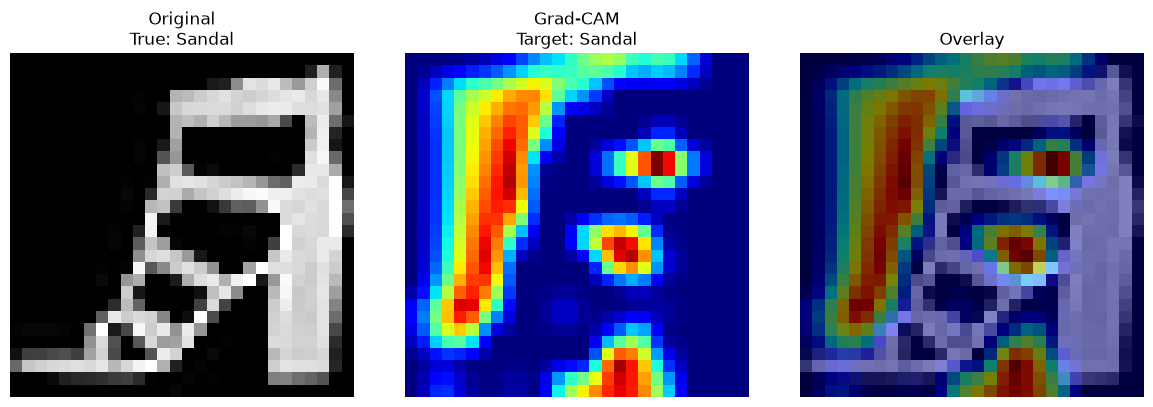

In [72]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

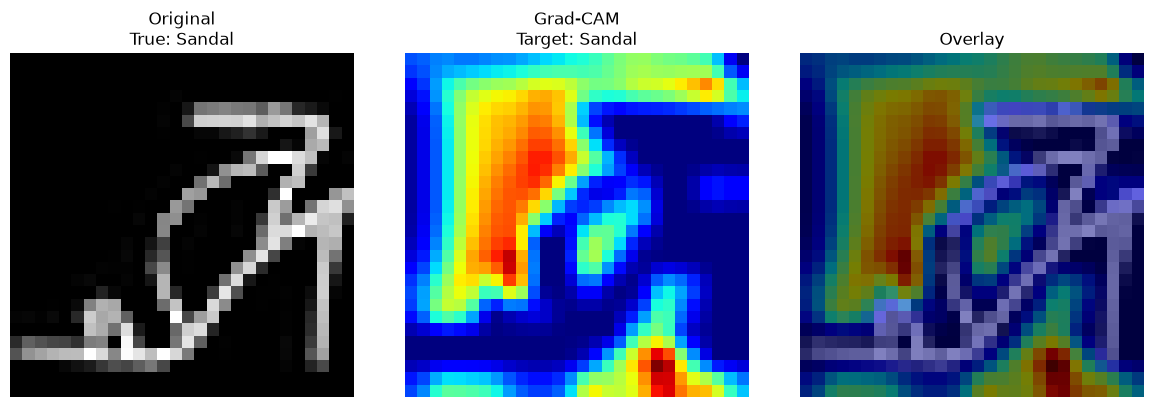

In [73]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

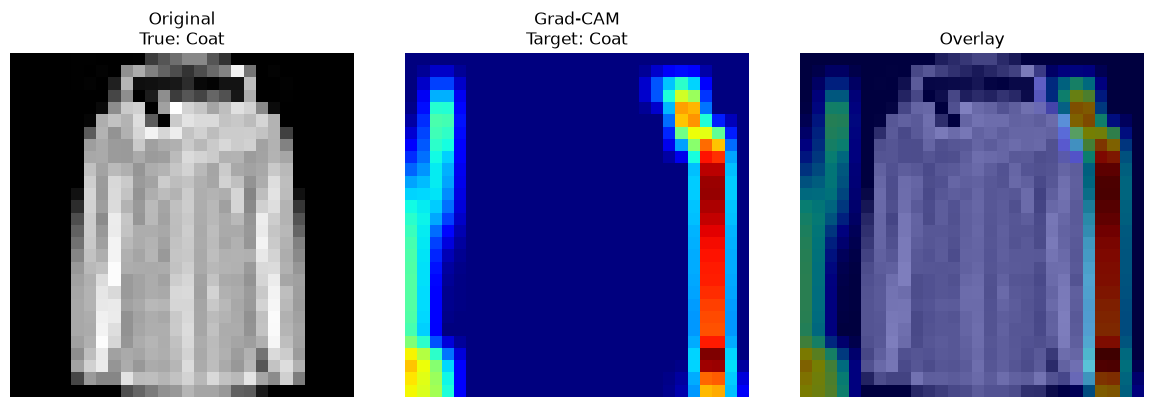

In [74]:
grad_cam(model= model, data_sample= test_data[np.random.randint(0, len(test_data))], target= model.block2[2], device= device)

OUR MODEL HAS LEARNED THE PREDICT USING THE NEGATIVE SPACE. [LETS TRAIN A NEW MODEL AND INTRODUCE DATA AUGMENTAIONS AND DROPOUT]